# Notebook 3 — Evaluation & Reporting (Age ≥ 65)

This notebook evaluates:
1) targeting quality (risk score → outcomes),
2) recommendation coverage & subgroup fairness,
3) association / quasi-causal impact estimation (PSM/IPW/DiD where feasible),
4) robustness checks & reporting tables/figures.

Inputs:
- notebook1: hrs_baseline_analytic.csv
- notebook2: notebook2_recommendations.csv

Outputs:
- notebook3_eval_summary.csv
- notebook3_subgroup_fairness.csv
- notebook3_effect_estimates.csv
- figures (PNG)

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
from dataclasses import dataclass
from typing import List, Optional, Dict, Tuple

SEED = 42
np.random.seed(SEED)

DATA_DIR = "../data_processed"
FIG_DIR = "../figures"
os.makedirs(FIG_DIR, exist_ok=True)

BASELINE_FILE = os.path.join(DATA_DIR, "notebook1_baseline_analytic.csv")
REC_FILE = os.path.join(DATA_DIR, "notebook2_recommendations.csv")

OUT_SUMMARY = os.path.join(DATA_DIR, "notebook3_eval_summary.csv")
OUT_FAIR = os.path.join(DATA_DIR, "notebook3_subgroup_fairness.csv")
OUT_EFFECT = os.path.join(DATA_DIR, "notebook3_effect_estimates.csv")

In [4]:
base = pd.read_csv(BASELINE_FILE)
rec  = pd.read_csv(REC_FILE)

# Basic sanity checks
assert base.shape[0] > 0, "Baseline data empty!"
assert rec.shape[0] > 0, "Recommendation data empty!"

assert "hhidpn" in base.columns, "hhidpn missing in baseline"
assert "hhidpn" in rec.columns, "hhidpn missing in rec"

assert base["hhidpn"].nunique() == rec["hhidpn"].nunique(), \
    "Mismatch in unique IDs between baseline and rec"

df = base.merge(rec, on="hhidpn", how="left", suffixes=("_base", "_rec"))

assert df.shape[0] == base.shape[0], "Row count changed after merge"

print("Data loaded successfully. Shape:", df.shape)

Data loaded successfully. Shape: (29371, 20)


In [5]:
def normalize_cols(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = [str(c).strip() for c in df.columns]
    return df

def find_col(df: pd.DataFrame, candidates: List[str]) -> Optional[str]:
    cols = {c.lower().strip(): c for c in df.columns}
    for cand in candidates:
        key = cand.lower().strip()
        if key in cols:
            return cols[key]
    cols2 = {c.lower().replace(" ", "").replace("_", ""): c for c in df.columns}
    for cand in candidates:
        key = cand.lower().replace(" ", "").replace("_", "")
        if key in cols2:
            return cols2[key]
    return None

def coerce_numeric(s: pd.Series) -> pd.Series:
    # handles strings like ".D" ".R" ".X" etc -> NaN
    return pd.to_numeric(s.replace({r"^\.\w+$": np.nan}, regex=True), errors="coerce")

def safe_qcut(x: pd.Series, q: int = 10) -> pd.Series:
    x2 = x.copy()
    # if many ties, duplicates='drop' prevents crash
    return pd.qcut(x2.rank(method="first"), q=q, labels=False, duplicates="drop")

In [6]:
import os
import pandas as pd

print("CWD:", os.getcwd())
print("BASELINE_FILE:", BASELINE_FILE, "exists?", os.path.exists(BASELINE_FILE))
print("REC_FILE     :", REC_FILE, "exists?", os.path.exists(REC_FILE))

# 1) Load
base = pd.read_csv(BASELINE_FILE)
rec  = pd.read_csv(REC_FILE)

# 2) Quick visibility (optional but useful)
print("\nBase shape:", base.shape)
print("Rec  shape:", rec.shape)

print("\nBASE cols (first 30):", list(base.columns)[:30])
print("REC  cols (first 30):", list(rec.columns)[:30])

# 3) Required columns
assert "hhidpn" in base.columns, "hhidpn missing in baseline"
assert "hhidpn" in rec.columns,  "hhidpn missing in rec"

# 4) ID checks
print("\nUnique IDs - base:", base["hhidpn"].nunique())
print("Unique IDs - rec :", rec["hhidpn"].nunique())

# 5) Merge (this will be used by later cells)
df = base.merge(rec, on="hhidpn", how="left", suffixes=("_base", "_rec"))

print("\nMerged shape:", df.shape)
print("Rec rows missing after merge:", df["risk_score"].isna().mean() if "risk_score" in df.columns else "risk_score not in df")

CWD: c:\Users\Yu\Desktop\BMI5111_Capstone_YuJun\notebooks
BASELINE_FILE: ../data_processed\notebook1_baseline_analytic.csv exists? True
REC_FILE     : ../data_processed\notebook2_recommendations.csv exists? True

Base shape: (29371, 10)
Rec  shape: (29371, 11)

BASE cols (first 30): ['hhidpn', 'wave', 'age', 'gender', 'edu_years', 'diabetes', 'adl_any', 'cesd', 'hosp', 'high_risk']
REC  cols (first 30): ['hhidpn', 'risk_score', 'high_risk', 'top1', 'top2', 'top3', 'reco_list', 'reco_reason_list', 'has_specific_reco', 'intervention_exposed', 'comparator_usual_referral']

Unique IDs - base: 29371
Unique IDs - rec : 29371

Merged shape: (29371, 20)
Rec rows missing after merge: 0.0


In [7]:
base = pd.read_csv(BASELINE_FILE)
rec = pd.read_csv(REC_FILE)

base = normalize_cols(base)
rec = normalize_cols(rec)

# ID column
id_col = find_col(base, ["HHIDPN", "hhidpn", "id", "respondent_id"])
id_col2 = find_col(rec, ["HHIDPN", "hhidpn", "id", "respondent_id"])
if id_col is None or id_col2 is None:
    raise ValueError("Cannot find respondent ID column in baseline/recommendation files (e.g., HHIDPN).")

# Merge
df = base.merge(rec, left_on=id_col, right_on=id_col2, how="inner", suffixes=("", "_rec"))

# Age column
age_col = find_col(df, ["age", "Age", "RAGE", "rage", "RwAGE"])
if age_col is None:
    raise ValueError("Cannot find age column. Please check notebook1 output.")
df[age_col] = coerce_numeric(df[age_col])

df = df[df[age_col] >= 65].copy()
print("Merged rows (Age>=65):", df.shape)
df.head(3)

Merged rows (Age>=65): (29371, 20)


,hhidpn,wave,age,gender,edu_years,diabetes,adl_any,cesd,hosp,high_risk,risk_score,high_risk_rec,top1,top2,top3,reco_list,reco_reason_list,has_specific_reco,intervention_exposed,comparator_usual_referral
0,2010,5,65.0,2,1.0,0.0,0.0,1.0,0.0,0,0.166667,0,General community resource information,NaN,NaN,['General community resource information'],['Default / universal info (operationalises us...,0,0,1
1,3010,11,76.0,1,3.0,0.0,0.0,0.0,1.0,0,0.333333,0,Care coordination / follow-up,NaN,NaN,['Care coordination / follow-up'],['Post-discharge / care transition needs'],1,1,0
2,3020,12,75.0,2,5.0,0.0,0.0,0.0,1.0,0,0.333333,0,Care coordination / follow-up,NaN,NaN,['Care coordination / follow-up'],['Post-discharge / care transition needs'],1,1,0


## Outcomes & "Treatment" Definitions

**Treatment / Exposure (what we evaluate):**
- receiving any recommendation (binary)
- specific recommendation categories (e.g., social / exercise / chronic care follow-up)
- intensity (# recommendations)

**Outcomes (examples; pick what's available in your baseline dataset):**
- doctor/GP visits
- hospital stay (yes/no), count
- nursing home stay (yes/no)
- out-of-pocket medical expenditure (if present)

Because HRS utilization definitions vary across waves, we document variable definitions carefully and run robustness checks.

In [19]:
# risk score
risk_col = "risk_score"

# treatment indicator
rec_any_col = "has_specific_reco"   # 或 intervention_exposed

# recommendation intensity
nrec_col = None
if "top1" in df.columns:
    df["n_recs"] = df[["top1", "top2", "top3"]].notna().sum(axis=1)
    nrec_col = "n_recs"

# recommendation category columns
rec_cat_cols = ["top1", "top2", "top3"]

print("risk_col:", risk_col)
print("rec_any_col:", rec_any_col)
print("nrec_col:", nrec_col)
print("rec_cat_cols:", rec_cat_cols)

risk_col: risk_score
rec_any_col: has_specific_reco
nrec_col: n_recs
rec_cat_cols: ['top1', 'top2', 'top3']


In [41]:
# Debug: search possible outcome columns by keywords
kw = ["visit", "doc", "gp", "hospital", "hosp", "nh", "nursing", "oop", "out", "pocket", "er", "ed", "admit"]
hits = [c for c in df.columns if any(k in c.lower() for k in kw)]
print("Possible outcome-related columns (keyword hit):")
print(hits[:200])
print("Total hits:", len(hits))

Possible outcome-related columns (keyword hit):
['gender', 'edu_years', 'hosp', 'intervention_exposed', 'comparator_usual_referral']
Total hits: 5


In [42]:
# ----------------------------
# Outcomes auto-detection (robust)
# ----------------------------
def find_by_keywords(df, include_any):
    cols = [c for c in df.columns if any(k in c.lower() for k in include_any)]
    return cols

# 1) Try exact candidate lists first (your original logic, expanded a bit)
outcome_candidates = {
    "doctor_visits": ["docvisits", "doctor_visits", "dr_visits", "gp_visits", "outpatient_visits", "RwDOCCNT", "Rwdrcnt"],
    "hospital_any": ["hospital_any", "hosp_any", "any_hospital", "inpatient_any", "RwHOSP", "Rwhosp"],
    "hospital_nights": ["hosp_nights", "hospital_nights", "nights_hosp", "los", "length_of_stay", "RwHOSPN"],
    "nh_any": ["nursinghome_any", "nh_any", "nursing_home", "RwNHM", "Rwnhm"],
    "oop_med": ["oop_med", "out_of_pocket", "oop_total", "medical_oop", "RwOOPMD", "H2OOPMD"],
    "ed_any": ["ed_any", "er_any", "emergency_any", "ed_visit", "er_visit"],
}

outcomes = {}
for k, cands in outcome_candidates.items():
    col = find_col(df, cands)
    if col is not None:
        outcomes[k] = col
        df[col] = coerce_numeric(df[col])

# 2) If still empty, fall back to fuzzy keyword search
if len(outcomes) == 0:
    fuzzy_rules = {
        "doctor_visits": ["visit", "doc", "gp", "outpatient"],
        "hospital_any": ["hospital", "hosp", "inpatient", "admit"],
        "oop_med": ["oop", "outofpocket", "out_of_pocket", "pocket"],
        "nh_any": ["nursing", "nh", "nursinghome"],
        "ed_any": ["ed", "er", "emergency"],
    }
    for name, kws in fuzzy_rules.items():
        cols = find_by_keywords(df, kws)
        if len(cols) > 0:
            # pick the first hit; you can manually change later if needed
            outcomes[name] = cols[0]
            df[cols[0]] = coerce_numeric(df[cols[0]])

print("Detected outcomes:", outcomes)

# 3) Hard stop if still none (prevents writing empty CSV)
if len(outcomes) == 0:
    raise ValueError(
        "No outcomes detected. Your baseline/notebook1 file likely doesn't include utilization outcomes "
        "(doctor visits / hospital / OOP etc) OR column names are different.\n"
        "Run the debug cell above to see which columns exist, then add them into outcome_candidates."
    )

outcomes

Detected outcomes: {'hospital_any': 'hosp', 'ed_any': 'gender'}


{'hospital_any': 'hosp', 'ed_any': 'gender'}

## 1) Targeting Quality

We check whether higher risk score (or risk deciles) correspond to worse outcomes:
- monotonic trend plots
- correlation / simple regression (not causal)
- calibration-style plots (mean outcome by risk decile)

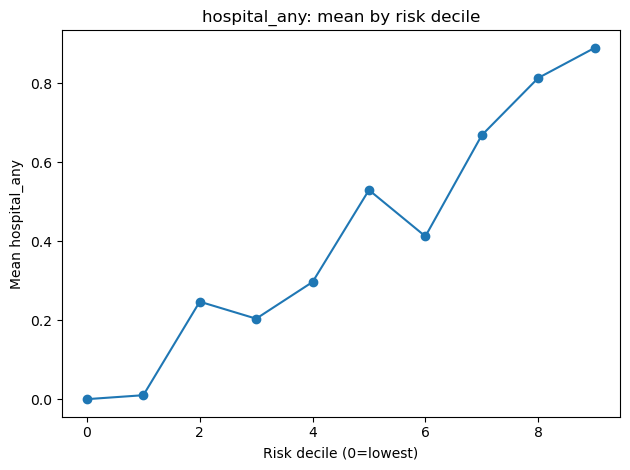

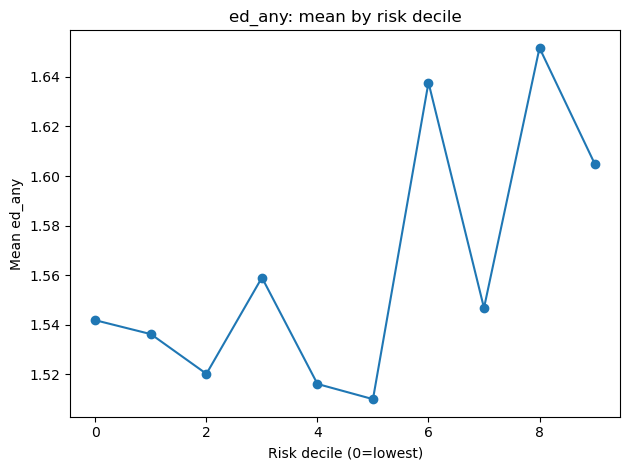

In [43]:
if risk_col is None:
    raise ValueError("No risk score column found; cannot evaluate targeting.")

df["risk_decile"] = safe_qcut(df[risk_col], q=10)

for name, ycol in outcomes.items():
    tmp = df.groupby("risk_decile")[ycol].mean().reset_index()
    plt.figure()
    plt.plot(tmp["risk_decile"], tmp[ycol], marker="o")
    plt.xlabel("Risk decile (0=lowest)")
    plt.ylabel(f"Mean {name}")
    plt.title(f"{name}: mean by risk decile")
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, f"nb3_targeting_{name}_by_riskdecile.png"), dpi=150)
    plt.show()

## 2) Coverage & Subgroup Fairness

We summarize:
- overall recommendation rate
- by key subgroups (sex, age bands, race/ethnicity if available, education, chronic conditions, ADL limitation)
- disparity metrics: absolute difference, ratio

In [44]:
# ---- FIX: create rec_any if not exported from notebook2 ----
if rec_any_col is None:
    # 优先用 has_specific_reco（最靠谱）
    cand = find_col(df, ["rec_any", "recommend_any", "any_recommendation",
                         "has_specific_reco", "intervention_exposed"])
    if cand is not None:
        df["rec_any"] = coerce_numeric(df[cand]).fillna(0).astype(int)
        rec_any_col = "rec_any"
    else:
        # 退一步：用 reco_list 是否为空来判断
        rl = find_col(df, ["reco_list", "recommendation_list"])
        if rl is None:
            raise ValueError("Cannot build rec_any: no has_specific_reco/intervention_exposed/reco_list found.")
        df["rec_any"] = df[rl].astype(str).str.strip().ne("").astype(int)
        # 处理 'nan' 字符串
        df.loc[df[rl].isna(), "rec_any"] = 0
        rec_any_col = "rec_any"

print("Using rec_any_col:", rec_any_col, "Rec rate:", df[rec_any_col].mean())

# subgroup columns to try
subgroup_candidates = {
    "sex": ["sex", "gender", "RSEX"],
    "age_band": [],  # we'll create
    "education": ["edu", "education", "edu_years", "RAEDUC", "education_years"],
    "adl_any": ["adl_any", "any_adl", "RwADL", "adl_lim"],
    "diabetes": ["diabetes", "dm", "RwDIAB", "diab"],
}

subgroups = {}
for k, cands in subgroup_candidates.items():
    if k == "age_band":
        continue
    col = find_col(df, cands)
    if col is not None:
        subgroups[k] = col

# age band
df["age_band"] = pd.cut(df[age_col], bins=[65, 70, 75, 80, 85, 200], right=False)

def subgroup_rate(df, gcol, tcol):
    out = df.groupby(gcol)[tcol].agg(["count", "mean"]).reset_index()
    out = out.rename(columns={"mean": "rec_rate", "count": "n"})
    return out

fair_tables = []
for gname, gcol in [("age_band", "age_band")] + list(subgroups.items()):
    tab = subgroup_rate(df, gcol, rec_any_col)
    tab["subgroup"] = gname
    tab = tab.rename(columns={gcol: "group"})
    fair_tables.append(tab)

fair = pd.concat(fair_tables, ignore_index=True)
fair.to_csv(OUT_FAIR, index=False)
fair.head(20)

Using rec_any_col: has_specific_reco Rec rate: 0.7036873106125089


,group,n,rec_rate,subgroup
0,"[65, 70)",5583,0.595021,age_band
1,"[70, 75)",5411,0.644798,age_band
2,"[75, 80)",5235,0.702579,age_band
3,"[80, 85)",5463,0.742815,age_band
4,"[85, 200)",7679,0.797109,age_band
5,1,12851,0.692475,sex
6,2,16520,0.712409,sex
7,1.0,8409,0.791890,education
8,2.0,1242,0.738325,education
9,3.0,8398,0.697309,education


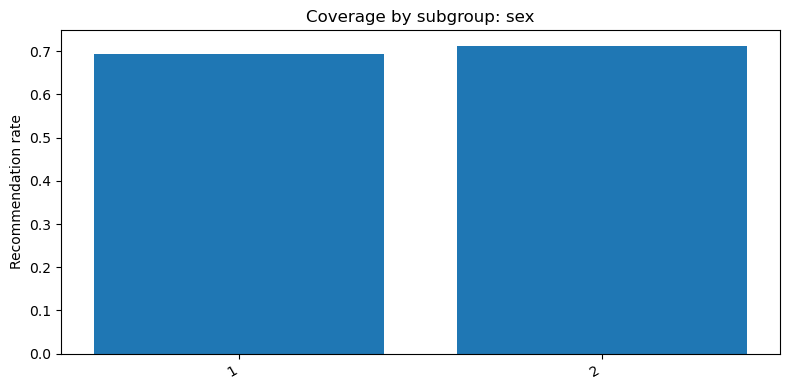

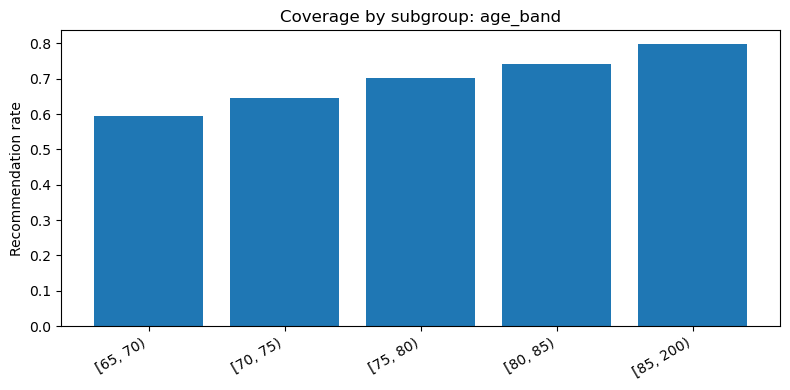

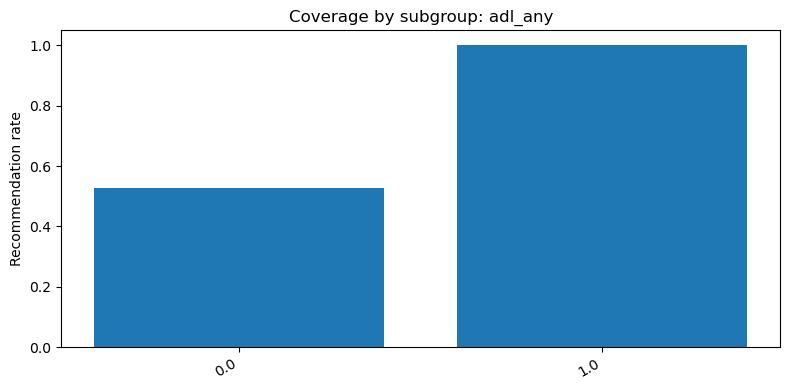

In [45]:
# --- NEW: Subgroup coverage bar plots ---
for sg in ["sex", "age_band", "adl_any"]:
    tmp = fair.loc[fair["subgroup"] == sg].copy()

    # group 列可能是 interval（比如 age_band），转成字符串更稳
    tmp["group_str"] = tmp["group"].astype(str)

    plt.figure(figsize=(8, 4))
    plt.bar(tmp["group_str"], tmp["rec_rate"])
    plt.xticks(rotation=30, ha="right")
    plt.ylabel("Recommendation rate")
    plt.title(f"Coverage by subgroup: {sg}")
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, f"nb3_coverage_by_{sg}.png"), dpi=150)
    plt.show()

## 3) Effect Estimation (Quasi-causal)

We estimate the association between receiving recommendations and outcomes.
Preferred (if you have longitudinal outcome across waves): DiD / fixed effects.
Otherwise: baseline cross-section with IPW / PSM (observational).

We report:
- naive difference in means
- IPW (propensity score weighting)
- sensitivity: overlap, covariate balance (SMD)

In [46]:
# Try to assemble covariates from common baseline fields
cov_candidates = [
    ["age", "Age", "RAGE", "RwAGE"],
    ["sex", "gender", "RSEX", "gender_rec", "sex_rec"],
    ["edu_years", "education_years", "edu", "RAEDUC"],
    ["married", "partnered", "marital", "RAMSTAT"],
    ["adl_any", "any_adl"],
    ["diabetes", "dm"],
    ["hypertension", "htn", "highbp"],
    ["heart", "heart_disease"],
    ["stroke"],
    ["depression", "cesd", "RwCESD"],
]

cov_cols = []
for cands in cov_candidates:
    col = find_col(df, cands)
    if col is not None and col not in cov_cols and col != rec_any_col:
        cov_cols.append(col)

# ----------------------------
# Build X with proper cleaning
# ----------------------------
X = df[cov_cols].copy()

# ---- pick a usable sex/gender column (not all missing) ----
sex_cands = [c for c in ["gender", "sex", "RSEX", "gender_rec", "sex_rec"] if c in df.columns]
sex_col = None
for c in sex_cands:
    if df[c].notna().any():   # must have at least some non-missing
        sex_col = c
        break

# ---- encode sex/gender to 0/1 ----
if sex_col is not None:
    s_raw = df[sex_col]

    # Convert to string for robust parsing
    s = s_raw.astype(str).str.strip().str.lower()

    # Extract a leading 1/2 if present (handles "1.male", "2.female", "1", "2")
    digit = s.str.extract(r"^\s*([12])", expand=False)

    # Map words if no digit
    word_map = {"male": "1", "m": "1", "female": "2", "f": "2"}
    digit = digit.fillna(s.replace(word_map))

    s_num = pd.to_numeric(digit, errors="coerce")

    # 1->1 (male), 2->0 (female); change if you want female=1
    X[sex_col] = s_num.replace({1: 1, 2: 0})
else:
    print("Warning: No usable sex/gender column found (all candidates are missing).")

# ---- Other columns numeric coercion ----
for c in X.columns:
    if c == sex_col:
        continue
    X[c] = coerce_numeric(X[c])

print("Covariates:", cov_cols)
print("Sex/Gender col used:", sex_col)

# Debug: show raw sex column top values (IMPORTANT)
if sex_col is not None:
    print("\nRaw sex/gender sample values:")
    print(df[sex_col].head(15).tolist())
    print("\nRaw sex/gender value counts (top 10):")
    print(df[sex_col].value_counts(dropna=False).head(10))
    print("\nEncoded sex/gender value counts (top 10):")
    print(X[sex_col].value_counts(dropna=False).head(10))

X.describe(include="all").T.head(20)

Covariates: ['age', 'gender', 'edu_years', 'adl_any', 'diabetes', 'cesd']
Sex/Gender col used: gender

Raw sex/gender sample values:
[2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 2, 2, 1, 2]

Raw sex/gender value counts (top 10):
gender
2    16520
1    12851
Name: count, dtype: int64

Encoded sex/gender value counts (top 10):
gender
0    16520
1    12851
Name: count, dtype: int64


,count,mean,std,min,25%,50%,75%,max
age,29371.0,78.388138,8.577403,65.0,71.0,78.0,85.0,109.0
gender,29371.0,0.437540,0.496092,0.0,0.0,0.0,1.0,1.0
edu_years,29362.0,2.951706,1.454433,1.0,1.0,3.0,4.0,5.0
adl_any,29322.0,0.372553,0.483493,0.0,0.0,0.0,1.0,1.0
diabetes,29299.0,0.323287,0.599389,0.0,0.0,0.0,1.0,6.0
cesd,23887.0,1.766693,2.081010,0.0,0.0,1.0,3.0,8.0


In [47]:
# 在 notebook2/3 都能跑（读入 baseline df 后）
print("adl_any in df?", "adl_any" in df.columns)
if "adl_any" in df.columns:
    print(df["adl_any"].head(20))
    print(df["adl_any"].value_counts(dropna=False).head(20))

adl_any in df? True
0     0.0
1     0.0
2     0.0
3     0.0
4     0.0
5     0.0
6     0.0
7     0.0
8     0.0
9     0.0
10    0.0
11    0.0
12    0.0
13    0.0
14    1.0
15    1.0
16    1.0
17    1.0
18    1.0
19    0.0
Name: adl_any, dtype: float64
adl_any
0.0    18398
1.0    10924
NaN       49
Name: count, dtype: int64


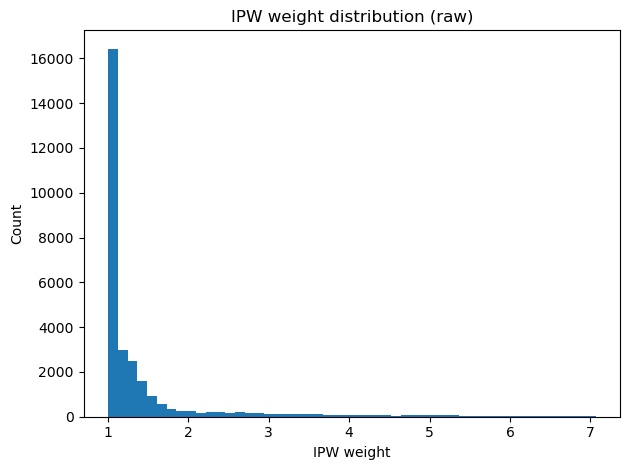

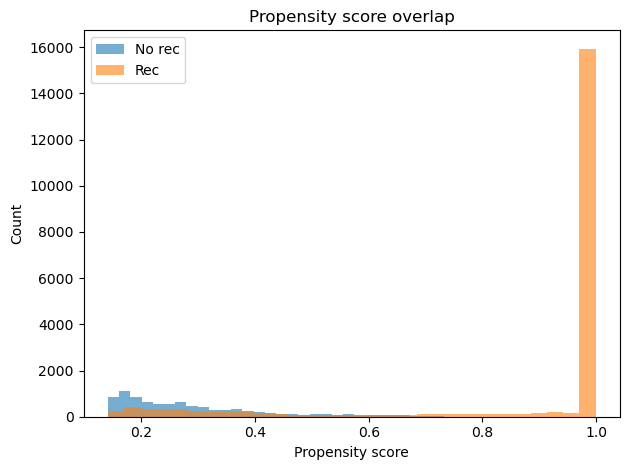

In [48]:
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

t = df[rec_any_col].astype(int).values

pipe = Pipeline([
    ("imp", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler(with_mean=True, with_std=True)),
    ("lr", LogisticRegression(max_iter=2000, solver="lbfgs"))
])

pipe.fit(X, t)
ps = pipe.predict_proba(X)[:, 1]
df["pscore"] = np.clip(ps, 1e-3, 1-1e-3)

# IPW weights (stabilized optional; here basic ATE weights)
df["w_ipw"] = t / df["pscore"] + (1 - t) / (1 - df["pscore"])

# --- NEW: IPW weight distribution (before trimming) ---
plt.figure()
plt.hist(df["w_ipw"].dropna(), bins=50)
plt.xlabel("IPW weight")
plt.ylabel("Count")
plt.title("IPW weight distribution (raw)")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "nb3_ipw_weight_raw.png"), dpi=150)
plt.show()

# overlap plot
plt.figure()
plt.hist(df.loc[df[rec_any_col]==0, "pscore"].dropna(), bins=30, alpha=0.6, label="No rec")
plt.hist(df.loc[df[rec_any_col]==1, "pscore"].dropna(), bins=30, alpha=0.6, label="Rec")
plt.xlabel("Propensity score")
plt.ylabel("Count")
plt.title("Propensity score overlap")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "nb3_pscore_overlap.png"), dpi=150)
plt.show()

In [49]:
def weighted_mean(y, w):
    m = np.sum(y*w) / np.sum(w)
    return m

rows = []
for name, ycol in outcomes.items():
    y = df[ycol].values
    mask = ~np.isnan(y) & ~np.isnan(df["w_ipw"].values)
    d = df.loc[mask, rec_any_col].values.astype(int)
    w = df.loc[mask, "w_ipw"].values

    # naive
    y1 = df.loc[mask & (df[rec_any_col]==1), ycol].mean()
    y0 = df.loc[mask & (df[rec_any_col]==0), ycol].mean()
    naive_ate = y1 - y0

    # IPW ATE
    ipw_y1 = weighted_mean(df.loc[mask & (df[rec_any_col]==1), ycol].values,
                           df.loc[mask & (df[rec_any_col]==1), "w_ipw"].values)
    ipw_y0 = weighted_mean(df.loc[mask & (df[rec_any_col]==0), ycol].values,
                           df.loc[mask & (df[rec_any_col]==0), "w_ipw"].values)
    ipw_ate = ipw_y1 - ipw_y0

    rows.append({
        "outcome": name,
        "y_col": ycol,
        "naive_diff": naive_ate,
        "ipw_ate": ipw_ate,
        "n_nonmissing": int(mask.sum())
    })

eff = pd.DataFrame(rows)
eff.to_csv(OUT_EFFECT, index=False)
eff

,outcome,y_col,naive_diff,ipw_ate,n_nonmissing
0,hospital_any,hosp,0.578636,0.701656,29042
1,ed_any,gender,0.023527,0.021619,29371


## 4) Robustness Checks & Reporting

Recommended checks:
- Missingness: outcome missing rate by treatment group
- Sensitivity: trim extreme IPW weights (e.g., cap at 99th percentile)
- Subgroup effect heterogeneity (optional): IPW within subgroup
- Document limitations:
  - observational / non-random exposure
  - HRS wave-specific question differences
  - proxy interview / skip patterns leading to missing codes

Deliverables:
- Tables: overall coverage, subgroup coverage, effect estimates
- Figures: risk decile trend plots, subgroup coverage barplot, pscore overlap

In [51]:
# Missingness by treatment group
miss_rows = []
for name, ycol in outcomes.items():
    for g in [0,1]:
        sub = df[df[rec_any_col]==g]
        miss_rows.append({
            "outcome": name,
            "group": g,
            "n": int(sub.shape[0]),
            "missing_rate": float(sub[ycol].isna().mean())
        })
miss = pd.DataFrame(miss_rows)
miss

,outcome,group,n,missing_rate
0,hospital_any,0,8703,0.015512
1,hospital_any,1,20668,0.009386
2,ed_any,0,8703,0.000000
3,ed_any,1,20668,0.000000


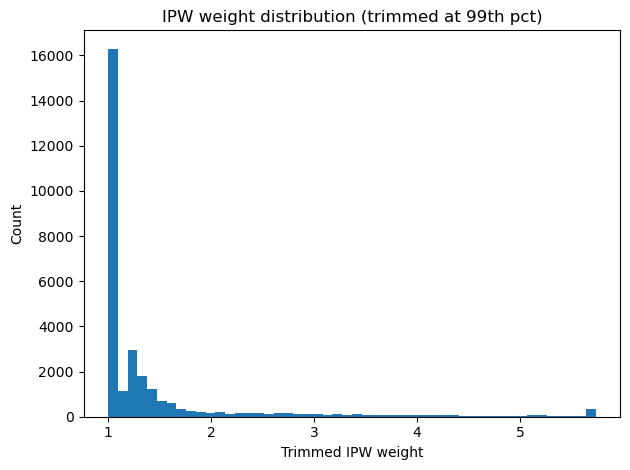

,outcome,ipw_ate_trim,cap_99p,n_nonmissing
0,hospital_any,0.700071,5.732616,29042
1,ed_any,0.019799,5.732616,29371


In [52]:
# Trim extreme weights and recompute IPW ATE
w = df["w_ipw"].copy()
cap = w.quantile(0.99)
df["w_ipw_trim"] = np.minimum(w, cap)

# --- NEW: IPW weight distribution (after trimming) ---
plt.figure()
plt.hist(df["w_ipw_trim"].dropna(), bins=50)
plt.xlabel("Trimmed IPW weight")
plt.ylabel("Count")
plt.title("IPW weight distribution (trimmed at 99th pct)")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "nb3_ipw_weight_trim.png"), dpi=150)
plt.show()

rows = []
for name, ycol in outcomes.items():
    y = df[ycol].values
    mask = ~np.isnan(y) & ~np.isnan(df["w_ipw_trim"].values)

    ipw_y1 = weighted_mean(df.loc[mask & (df[rec_any_col]==1), ycol].values,
                           df.loc[mask & (df[rec_any_col]==1), "w_ipw_trim"].values)
    ipw_y0 = weighted_mean(df.loc[mask & (df[rec_any_col]==0), ycol].values,
                           df.loc[mask & (df[rec_any_col]==0), "w_ipw_trim"].values)
    rows.append({
        "outcome": name,
        "ipw_ate_trim": ipw_y1 - ipw_y0,
        "cap_99p": float(cap),
        "n_nonmissing": int(mask.sum())
    })

pd.DataFrame(rows)

In [53]:
summary = {
    "n_merged_age65plus": df.shape[0],
    "rec_rate_overall": float(df[rec_any_col].mean()) if rec_any_col else np.nan,
    "n_outcomes_detected": len(outcomes),
    "outcomes": ";".join([f"{k}:{v}" for k,v in outcomes.items()])
}
pd.DataFrame([summary]).to_csv(OUT_SUMMARY, index=False)

print("Saved:", OUT_SUMMARY)
print("Saved:", OUT_FAIR)
print("Saved:", OUT_EFFECT)

Saved: ../data_processed\notebook3_eval_summary.csv
Saved: ../data_processed\notebook3_subgroup_fairness.csv
Saved: ../data_processed\notebook3_effect_estimates.csv
